In [45]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import seaborn as sn

In [46]:
col_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

data = pd.read_csv('diabetes.csv', header=None, names=col_names)

print(data.shape)

(768, 9)


In [47]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [48]:
feature_cols = ['Pregnancies', 'Insulin', 'BMI', 'Age', 'Glucose', 'BloodPressure', 'DiabetesPedigreeFunction']

x = data[feature_cols]
y = data.Outcome

In [49]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=5)

In [50]:
model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

[[88 12]
 [19 35]]
Accuracy: 0.7987012987012987


<Axes: xlabel='Predicted', ylabel='Actual'>

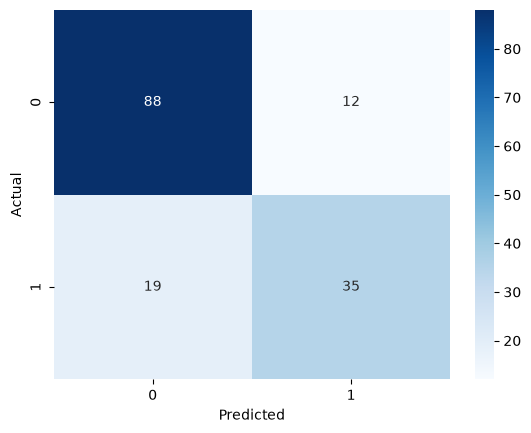

In [51]:
conf_matrix = metrics.confusion_matrix(y_test, y_pred)
print(conf_matrix)

accuracy_score = metrics.accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy_score)

conf_mat = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
sn.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')